# Modelo de regresion no lineal

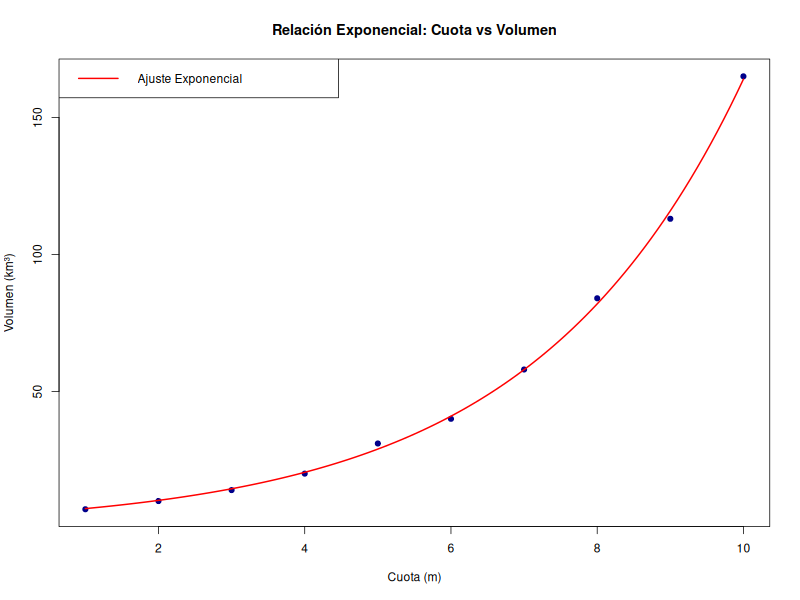

In [1]:
# --- Script en R: Evaluación de Regresión No Lineal ---

# 1. Definición de datos (Escenario clínico/topográfico) [6]
cuota <- c(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
volumen <- c(7, 10, 14, 20, 31, 40, 58, 84, 113, 165)
datos <- data.frame(cuota, volumen)

# 2. Visualización inicial de la dispersión [6]
plot(datos$cuota, datos$volumen, 
     main="Relación Exponencial: Cuota vs Volumen",
     xlab="Cuota (m)", ylab="Volumen (km³)", pch=19, col="darkblue")

# 3. Ajuste del modelo no lineal usando nls() [6]
# Se especifica la fórmula y los valores de inicio para los parámetros
modelo_nls <- nls(volumen ~ a * exp(b * cuota), 
                  data = datos, 
                  start = list(a = 1, b = 1))

# 4. Evaluación del modelo [8, 9]
summary(modelo_nls) # Muestra estimaciones, error estándar y significancia

# 5. Representación gráfica de la curva ajustada [10]
# Extraemos los coeficientes optimizados
params <- coef(modelo_nls)
curve(params["a"] * exp(params["b"] * x), 
      from = 1, to = 10, add = TRUE, col = "red", lwd = 2)

legend("topleft", legend="Ajuste Exponencial", col="red", lwd=2)

# Modelo de regresion polinomica

Analysis of Variance Table

Model 1: trigliceridos ~ edad
Model 2: trigliceridos ~ edad + I(edad^2)
  Res.Df     RSS Df Sum of Sq      F    Pr(>F)    
1     98 24354.8                                  
2     97  8108.3  1     16246 194.36 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


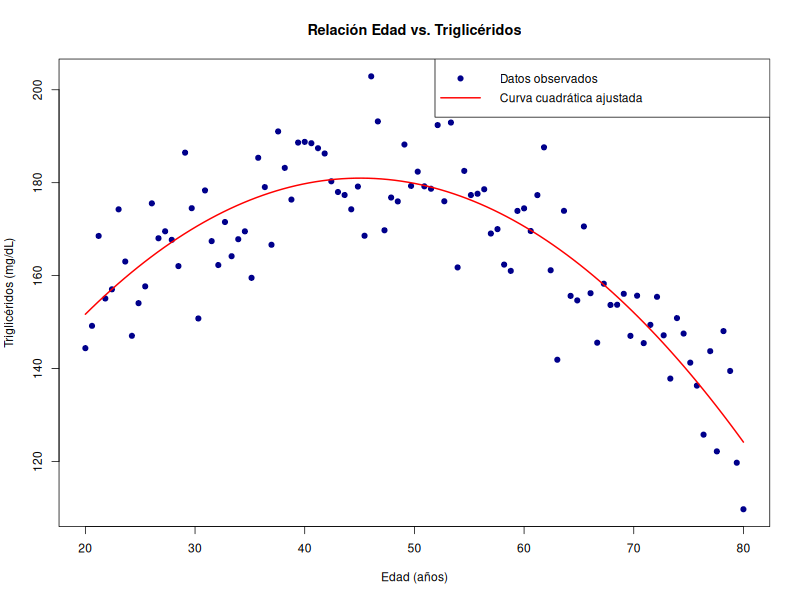

In [2]:
# --- Script de Regresión Polinómica Cuadrática ---

# 1. Generación de datos ficticios basados en lógica clínica
set.seed(123)
edad <- seq(20, 80, length.out = 100)
trigliceridos <- 80 + 4.5*edad - 0.05*edad^2 + rnorm(length(edad), 0, 10)

datos_clinicos <- data.frame(edad, trigliceridos)

# 2. Ajuste del modelo cuadrático
modelo_quad <- lm(trigliceridos ~ edad + I(edad^2), data = datos_clinicos)

# 3. Visualización de los parámetros estimados
summary(modelo_quad)

# 4. Comparación con el modelo lineal simple
modelo_lineal <- lm(trigliceridos ~ edad, data = datos_clinicos)
tabla_comparativa <- anova(modelo_lineal, modelo_quad)
print(tabla_comparativa)

# 5. Representación Gráfica
plot(datos_clinicos$edad, datos_clinicos$trigliceridos, 
    pch = 19, col = "darkblue",
    main = "Relación Edad vs. Triglicéridos",
    xlab = "Edad (años)", ylab = "Triglicéridos (mg/dL)")

# Extraemos los coeficientes beta del modelo (índices correctos: 1, 2, 3)
b0 <- coef(modelo_quad)[1]
b1 <- coef(modelo_quad)[2]
b2 <- coef(modelo_quad)[3]

# Superposición de la curva ajustada
curve(b0 + b1*x + b2*x^2, add = TRUE, col = "red", lwd = 2)

# Leyenda
legend("topright", legend = c("Datos observados", "Curva cuadrática ajustada"),
      col = c("darkblue", "red"), pch = c(19, NA), lty = c(NA, 1), lwd = c(NA, 2))
